# Clase Clasificación binaria

## Importación del modelo y ejecución

In [16]:
from models.clasificacion_binaria import ClasificacionBinaria

prueba_binaria = ClasificacionBinaria()

# Se invoca la función que divide el set de datos
X_train, X_val, X_test, y_train, y_val, y_test = prueba_binaria.dividir_df(prueba_binaria.df)


Distribución de clases:
Train: [3311 1196]
Val  : [828 299]
Test : [1035  374]


#### Los resultados muestran el balance en en la distribución de la variable objetivo (Chrun) para cada uno de los segmentos del de set de datos para entrenamiento

Epoch 1/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7414 - val_loss: 0.6389
Epoch 2/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6857 - val_loss: 0.6438
Epoch 3/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6710 - val_loss: 0.6425
Epoch 4/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6599 - val_loss: 0.6299
Epoch 5/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6416 - val_loss: 0.6117
Epoch 6/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6399 - val_loss: 0.6084
Epoch 7/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6296 - val_loss: 0.5986
Epoch 8/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6320 - val_loss: 0.5955
Epoch 9/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6359 - val_loss: 0.5945
Epoch 10/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6404 - val_loss: 0.5977
Epoch 11/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6344 - val_loss: 0.5961
Epoch 12/500
141/141 ━━━━━━━━━━━━━━━━━━━━

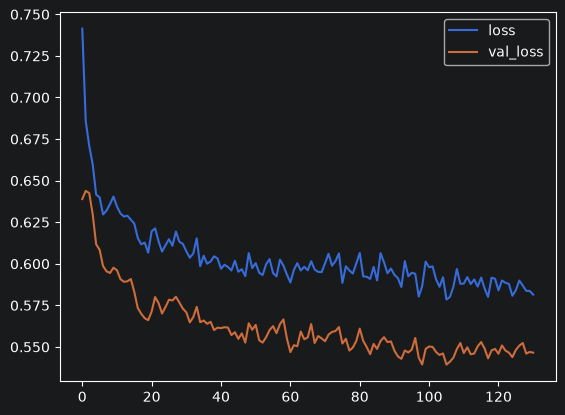

In [17]:
modelo_creado = prueba_binaria.crearModeloBinario(X_val,y_val, X_train, X_test, y_train, y_test)

### El gráfico anterior muestra el resultado de aplicar en el modelo neuronal un dropout de 0.5, un early stop y el balance de cargas dando como resultado:

#### - Ambas curvas descendentes sin cambios bruscos o aumento en la pendiente, lo que deja saber que el model está aprendiendo.
#### - No hay overfitting
#### - El espacio entre las líneas del *los* y *val_loss*
#### - El modelo puede ser mejorado buscando disminuir la distancia entre los *los* y *val_loss*, esto mediante el uso de ajustes como: *learning rate*,*epochs* y *batch size*


In [12]:
prueba_binaria.evaluar_modelo(X_test, y_test, modelo_creado)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.92      0.61      0.73      1035
           1       0.44      0.85      0.58       374

    accuracy                           0.67      1409
   macro avg       0.68      0.73      0.65      1409
weighted avg       0.79      0.67      0.69      1409

[[628 407]
 [ 57 317]]


---
<div align="center">

#### Reporte de clasificación y matriz de confusión

| Dato           | Valor | Porcentaje |
|----------------|-------|------------|
| Total muestras | 1409  |            |
| Clase 0        | 1035  | 73.5%      |
| Clase 1        | 374   | 26.5%      |

#### Dataset desbalanceado, proporción ~3:1
---
</div>

---
<div align="center">

### Análisis por cada clase

#### Clase 0: (negativo)

| Métrica       | Valor | Significado                            |
|---------------|-------|----------------------------------------|
| **Precisión** | 0.92  | Lo que predice como 0, 92% es correcto |
| **Recall**    | 0.61  | Solo detecta 61% de los casos reales   |
| **F1-Score**  | 0.73  | Tiene balance moderado                 |

---
#### Clase 1: (positivo)

| Métrica       | Valor | Significado                                |
|---------------|-------|--------------------------------------------|
| **Precisión** | 0.44  | Solo 44% de la predicción es correcta      |
| **Recall**    | 0.85  | Detecta 85% de los casos reales de clase 1 |
| **F1-Score**  | 0.58  | Tiene balance bajo                         |
---
</div>

El modelo muestra un claro sesgo hacia predecir la clase 0  lo que concuerda con el análisis EDA de datos "sesgados"

**Posibles mejoras para el modelo**
- Balancear clases de entrenamiento
- Ajustar pesos
---